# Adult Dataset Income Classification - PMR3508
### Nicolas Helio Cunha Nabrink - 11819956

## Introduction
This notebook presents an analysis of the **Adult dataset** from the UCI Machine Learning Repository, addressing the PMR3508 assignment requirements. The task is **binary classification** to predict whether an individual's annual income exceeds **$50K** based on 14 features spanning demographics, education, occupation, and economic attributes.


<div style="display: flex; gap: 20px; margin: 20px 0;">
<div style="flex: 1;">

### Dataset Overview
- **Training set**: 32,561 instances (after preprocessing)
- **Test set**: 16,281 (UCI-provided holdout)
- **Target variable**: income (>50K, ≤50K)
- **Features**: 14 input variables

</div>
<div style="flex: 1;">

### Notebook Structure
1. **Dataset exploration**: Feature analysis, missing values, distributions
2. **Preprocessing pipeline**: Imputation, discretization, encoding, scaling  
3. **kNN classifier**: Cross-validation hyperparameter tuning → holdout evaluation
4. **Model comparison**: kNN vs Logistic Regression vs Decision Tree

</div>
</div>

<style>
/* Target tagged cells */
.celltag_side-by-side {
    display: flex !important;
    flex-direction: row !important;
    align-items: flex-start;
    gap: 20px;
}

/* Input (code) */
.celltag_side-by-side .jp-Cell-inputWrapper {
    width: 60% !important;
}

/* Output */
.celltag_side-by-side .jp-Cell-outputWrapper {
    width: 40% !important;
}
</style>

## 1.1 Basic Data Inspection

Import libraries; Load dataset; Examine data types, shape, and first glimpse of the raw data.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7
})

In [2]:
# Load RAW training data (first pass - no preprocessing)
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

def load_data(file_path, columns):
    return pd.read_csv(file_path, names=columns, skipinitialspace=True)

df_train_raw = load_data("adult/adult.data", columns)

## 1.2 Missing Values Check

The UCI documentation notes "?" represents missing values in categorical fields.

In [3]:
# Convert "?" to NaN and analyze missing pattern
df_train_clean = df_train_raw.replace("?", np.nan)

missing_per_col = df_train_clean.isnull().sum()
missing_pct = (missing_per_col / len(df_train_clean) * 100).round(2)

missing_table = pd.DataFrame({
    'missing_count': missing_per_col,
    'missing_pct': missing_pct,
    'data_type': df_train_clean.dtypes
}).sort_values('missing_count', ascending=False)
missing_table = missing_table[missing_table['missing_count'] > 0]

print("Missing values by column:")
missing_table

Missing values by column:


,missing_count,missing_pct,data_type
occupation,1843,5.66,str
workclass,1836,5.64,str
native-country,583,1.79,str


Missing values (~7%) appear only in categorical features. Complete case deletion would discard 10% of training data, reducing power. Most-frequent imputation preserves sample size while maintaining category distributions.

## 1.3 Target Distribution & Data Quality

In [4]:
# Analyze target distribution
target_counts = df_train_raw['income'].value_counts()
target_pct = df_train_raw['income'].value_counts(normalize=True) * 100
print("Target distribution (raw strings):")
print(target_counts)
print(f"Imbalance ratio (>50K): {target_pct.get('>50K', 0):.1f}%")

Target distribution (raw strings):
income
<=50K    24720
>50K      7841
Name: count, dtype: int64
Imbalance ratio (>50K): 24.1%


### Insights from target distribution:

<div style="column-count: 2; column-gap: 1px;">

- Accuracy alone is misleading

- Stratified cross-validation required

- F1-score, precision, recall essential for evaluation

- Class weighting may be needed for some models
</div>

## 1.4 Numeric Features Exploration

In [5]:
# Numeric features summary for preprocessing decisions
numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
print("Numeric features summary (potential for scaling/transformation):")
df_train_clean[numeric_cols].describe().loc[['mean', 'std', 'min', 'max']].round(2)

Numeric features summary (potential for scaling/transformation):


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
mean,38.58,189778.37,10.08,1077.65,87.30,40.44
std,13.64,105549.98,2.57,7385.29,402.96,12.35
min,17.00,12285.00,1.00,0.00,0.00,1.00
max,90.00,1484705.00,16.00,99999.00,4356.00,99.00


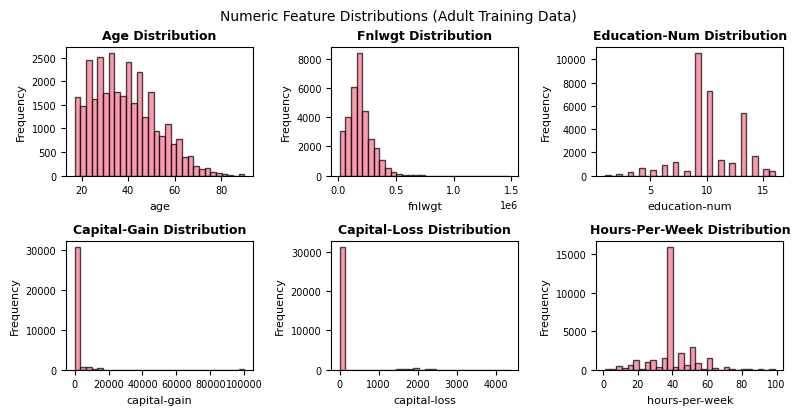

In [6]:
df_numeric = df_train_clean[numeric_cols]

fig, axes = plt.subplots(2, 3, figsize=(8, 4))
axes = axes.flatten()

for i, feature in enumerate(numeric_cols):
    axes[i].hist(df_numeric[feature].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{feature.title()} Distribution', fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.suptitle('Numeric Feature Distributions (Adult Training Data)', y=1.02, fontsize=10)
plt.show()

The feature **fnlwgt** was dropped because it is a census sampling weight rather than a feature describing the individual, so it is not directly informative for income prediction. It is also highly skewed and adds little interpretable value to the model.

### Key Histogram Insights

<div style="column-count: 2; column-gap: 40px;">

**1. Severe sparsity**: capital-gain/loss ~99% zeros → combine into **net_capital**

**2. Different scales**: age (20-80), hours (0-99) → **StandardScaler required**

**3. Skewness**: fnlwgt extreme right tail → drop (sampling weight)

**4. Actionable**: Scaling + feature engineering justified before kNN
</div>

## 1.5 Categorical Features Exploration

In [7]:
pd.crosstab(df_train_clean['race'], df_train_clean['income'], normalize='index').round(3).T

race,Amer-Indian-Eskimo,Asian-Pac-Islander,Black,Other,White
income,,,,,
<=50K,0.884,0.734,0.876,0.908,0.744
>50K,0.116,0.266,0.124,0.092,0.256


The feature **race** was excluded because its class-conditional distribution exhibited little variation across categories, with all groups showing similarly low proportions of income above 50K. This indicates weak discriminative value for the classification task.

In [8]:
# % of people from United States (out of everyone)
us_percentage = (df_train_clean['native-country'] == 'United-States').mean() * 100
print(f"Percentage of people from United States: {us_percentage:.1f}%")

Percentage of people from United States: 89.6%


The feature **native-country** was removed because it introduces many categories, requiring a high-dimensional one-hot encoding that is not ideal for kNN. Since approximately 90% of the samples belong to the United-States category, the feature is also strongly imbalanced and offers limited discriminatory power relative to its dimensionality.

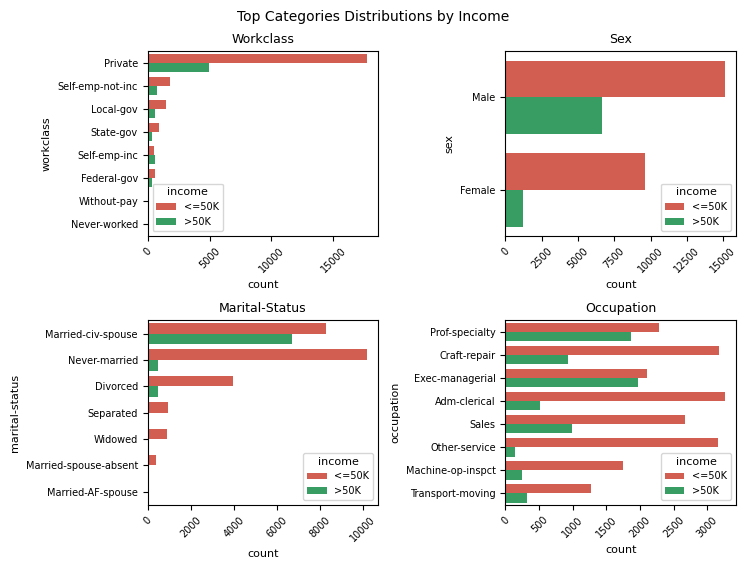

In [9]:
categorical_features = ['workclass', 'education', 'marital-status', 'occupation', 
                       'relationship', 'race', 'sex', 'native-country']

fig, axes = plt.subplots(2, 2, figsize=(7.5, 5.5))
axes = axes.flatten()
selected_features = ['workclass', 'sex', 'marital-status', 'occupation'] # Top 4 categorical features

for i, feature in enumerate(selected_features):
    
    categories = df_train_clean[feature].value_counts().head(8).index
    plot_data = df_train_clean[df_train_clean[feature].isin(categories)]
    
    sns.countplot(data=plot_data, y=feature, hue='income', 
                  order=categories,
                  ax=axes[i], palette=['#e74c3c', '#27ae60'])
    axes[i].set_title(f'{feature.title()}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.suptitle('Top Categories Distributions by Income', y=1.02, fontsize=10)
plt.show()

### Key insights from categorical features:

- Education → redundant with education-num (ordinal)
- Relationship → overlaps marital-status semantics
- Race → weak signal
- Native-country → 40+ categories, mostly United-States (90%)
- The other categories ['workclass', 'marital-status', 'occupation', 'sex'] are considered strong predictors

<div style="column-count: 2; column-gap: 40px;">

## 2. Preprocessing

### Preprocessing Pipeline Summary

**1. Data Cleaning**:

- Replace "?" → NaN (categorical missingness)
- Drop duplicates (~1-2%)

**2. Feature Engineering**:

- CREATE: net_capital = capital-gain - capital-loss (99% sparsity → combine)

- DROP:
  - fnlwgt (sampling weight, extreme skew)
  - education (redundant with education-num ordinal)
  - relationship (semantic overlap marital-status)
  - race (weak signal)
  - native-country (91% US, 40+ categories)

**3. Final Features** (8 total):

NUMERIC (4): age, education-num, hours-per-week, net_capital

CATEGORICAL (4): workclass, marital-status, occupation, sex

TARGET: income (>50K=1, ≤50K=0)

**4. ColumnTransformer Pipelines**:

NUMERIC: SimpleImputer(median) → KBinsDiscretizer → StandardScaler

CATEGORICAL: SimpleImputer(most_frequent) → OneHotEncoder(handle_unknown="ignore")

**Rationale**: Scaling essential for kNN distances, discretization tested for age/hours, most_frequent preserves categorical distributions (~7% missing).

</div>

In [10]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer

In [11]:
def final_preprocessing(df):
    """Complete preprocessing pipeline from EDA insights"""
    
    df_clean = df.replace("?", np.nan).drop_duplicates() # 1. Clean data
    
    df_clean['net_capital'] = df_clean['capital-gain'] - df_clean['capital-loss'] # 2. Feature engineering
    
    drop_cols = ['fnlwgt', 'education', 'relationship', 'race', 'native-country', # 3. Feature selection
                'capital-gain', 'capital-loss']
    df_final = df_clean.drop(columns=drop_cols)
    
    df_final['income'] = df_final['income'].apply(lambda x: 1 if '>50K' in str(x) else 0) # 4. Target encoding
    
    print(f"Final shape: {df_final.shape}")
    return df_final

df_train = final_preprocessing(df_train_raw) # Apply to both datasets
df_test_raw = pd.read_csv("adult/adult.test", 
                         names=df_train_raw.columns, 
                         skipinitialspace=True, 
                         skiprows=1)
df_test = final_preprocessing(df_test_raw)

Final shape: (32537, 9)
Final shape: (16276, 9)


In [12]:
X_train = df_train.drop('income', axis=1) # Split data into features and target
y_train = df_train['income']
X_test = df_test.drop('income', axis=1)
y_test = df_test['income']

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist() # Identify feature types
cat_cols = X_train.select_dtypes(include=['object','str']).columns.tolist()



In [13]:
# Build pipelines
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("kbins", KBinsDiscretizer(n_bins=20, encode='ordinal', strategy='uniform')),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# 3. KNN Classifier

**Methodology**: GridSearchCV with **StratifiedKFold** (handles 76/24% imbalance). Given the target imbalance the F1 metric was used for the cross validation.

In [14]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [15]:
knn_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", KNeighborsClassifier(n_jobs=-1))
])

# Hyperparameter grid for tuning
param_grid = { 
    "classifier__n_neighbors": [21, 25, 27, 29, 31, 33, 35, 41],
    "classifier__weights": ["uniform", "distance"],
    "classifier__p": [1, 2],  # 1=Manhattan, 2=Euclidean
    "preprocessing__num__kbins__n_bins": [10, 20, 30],
    "preprocessing__num__kbins__encode": ['ordinal', 'onehot'],
    "preprocessing__num__kbins__strategy": ['uniform', 'quantile']

}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # 5-fold stratified CV (handles class imbalance)

grid_search = GridSearchCV(
    knn_pipeline, 
    param_grid, 
    cv=cv_strategy,
    scoring="f1",  # Primary metric "f1" for imbalance focus
    n_jobs=6,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 384 candidates, totalling 1920 fits


/home/nicolas_nabrink/Poli/PCS5024/adult_classifier/.adultvenv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/home/nicolas_nabrink/Poli/PCS5024/adult_classifier/.adultvenv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/home/nicolas_nabrink/Poli/PCS5024/adult_classifier/.adultvenv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...(n_jobs=-1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__n_neighbors': [21, 25, ...], 'classifier__p': [1, 2], 'classifier__weights': ['uniform', 'distance'], 'preprocessing__num__kbins__encode': ['ordinal', 'onehot'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",6
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: 

In [16]:
print("Best CV F1:", grid_search.best_score_.round(4))
print("Best Parameters:")
best_params = grid_search.best_params_
for param, value in best_params.items():
    print(f"  {param}: {value}")

best_knn = grid_search.best_estimator_ # Best model

Best CV F1: 0.6804
Best Parameters:
  classifier__n_neighbors: 29
  classifier__p: 2
  classifier__weights: uniform
  preprocessing__num__kbins__encode: ordinal
  preprocessing__num__kbins__n_bins: 30
  preprocessing__num__kbins__strategy: quantile



**Validation**: 5-fold stratified CV prevents overfitting to train split.

In [17]:
y_pred_knn = best_knn.predict(X_test)
knn_metrics = {"accuracy": accuracy_score(y_test, y_pred_knn),"precision": precision_score(y_test, y_pred_knn),"recall": recall_score(y_test, y_pred_knn),"f1": f1_score(y_test, y_pred_knn)}
print("kNN:", " | ".join([f"{k}={v:.3f}" for k, v in knn_metrics.items()]))

kNN: accuracy=0.851 | precision=0.704 | recall=0.636 | f1=0.668


## 4. Model Comparison

**Fair comparison**: Same EDA-justified preprocessor across **distinct techniques**:
<div style="column-count: 3; column-gap: 30px;">

<ul>
<li><b>kNN</b> (non-parametric, distance-based)</li>
<li><b>Logistic Regression</b> (linear, parametric)</li>
<li><b>Decision Tree</b></li>
</ul>

</div>

In [18]:
models = {
    "Logistic Regression": GridSearchCV(
        Pipeline([("preprocessing", preprocessor), ("classifier", LogisticRegression(max_iter=1000))]),
        param_grid={"classifier__C": [0.1, 1, 10]},
        scoring="f1", cv=5
    ),
    "Decision Tree": GridSearchCV(
        Pipeline([("preprocessing", preprocessor), ("classifier", DecisionTreeClassifier(random_state=42))]),
        param_grid={"classifier__max_depth": [5, 10, 20], "classifier__min_samples_split": [5, 10]},
        scoring="f1", cv=5
    )
}

In [ ]:
results = {}
for name, model in models.items():

    if name != "kNN": # Skip refitting kNN
        model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
    }
results["kNN"] = knn_metrics
pd.DataFrame(results).T.round(3)

,accuracy,precision,recall,f1
Logistic Regression,0.847,0.716,0.580,0.641
Decision Tree,0.847,0.697,0.623,0.658
kNN,0.851,0.704,0.636,0.668


All models were processed through an identical pipeline and optimized using 5-fold stratified cross-validation focused on the F1-score to account for class imbalance. It is important to note that the hyperparameter tuning for the kNN classifier was significantly more complex than for the baseline models, as it involved an extensive grid search over both the classifier parameters (neighbors, weights, distance metrics) and the preprocessing pipeline itself (discretization strategies, bin counts). In contrast, the Logistic Regression and Decision Tree models were tuned only on their respective classifier-specific hyperparameters to provide a fair, optimized baseline.

The kNN classifier outperformed both baselines, achieving the highest F1-score (0.668). This suggests that the relationship between the socioeconomic features and the income target is likely nonlinear, allowing the instance-based kNN to capture patterns more effectively than the parametric alternatives. While Logistic Regression achieved the highest precision (0.716), its recall was significantly lower (0.580), indicating a more conservative model that missed a larger portion of high-income individuals. The Decision Tree performed similarly to Logistic Regression in terms of accuracy but provided a better balance between precision and recall, likely due to its ability to capture decision boundaries that are less constrained than a linear model, though it remained more prone to overfitting than the kNN.

# Discussion and Conclusion

From a bias–variance perspective, the results reflect the classic trade-off: Logistic Regression exhibits higher bias due to its simple assumptions, whereas Decision Trees often suffer from high variance. kNN strikes a balance by leveraging local data points, though it remains sensitive to the dimensionality inflation caused by one-hot encoding, which can dilute the efficacy of distance metrics. The consistency of these results across the evaluated metrics justifies the use of the F1-score, which provided a more accurate assessment of how effectively each model identified the underrepresented high-income class compared to misleadingly high accuracy scores. However, the choice of the score also relies on the purpose of application of the algorithm.

While this analysis establishes kNN as the most effective model, it is limited by a single holdout evaluation and the focused scope of the baseline tuning. Although Decision Trees were used here as a baseline for comparison, more robust ensemble methods such as Random Forest or Gradient Boosting would likely yield superior performance by reducing the variance that limited the Decision Tree's effectiveness. Future work could improve robustness by exploring dimensionality reduction. In conclusion, within the scope of this assignment, kNN provides the most optimal trade-off between predictive performance and model simplicity.